C:\Users\orvil\AppData\Local\Temp\ipykernel_23404\1569519267.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\ipykernel_23404\1569519267.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\ipykernel_23404\1569519267.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\ipykernel_23404\1569519267.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\ipykernel_23404\1569519267.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(malus_k4, angles, signal_detrend,
C:\Users\orvil\AppData\Local\Temp\i


============ BIREFRINGENCE CLASSIFICATION ============

  phantom  dominant_k_mode  k4_purity_mean  k4_purity_std  malus_r2_mean  malus_r2_std  k4_amp_mean              classification
  a_known                1        0.035327       0.029237       0.035117      0.028966     0.309784 Non-birefringent (no nerve)
  b_known                4        0.493599       0.105775       0.493048      0.106192     2.668230 Non-birefringent (no nerve)
  c_known                4        0.760045       0.029164       0.759636      0.029437     9.607315        Birefringent (nerve)
d_unknown                4        0.714219       0.200450       0.710368      0.200823    18.151206        Birefringent (nerve)
f_unknown                1        0.025080       0.019159       0.025004      0.019149     0.294369 Non-birefringent (no nerve)

--- d_unknown per‑detector analysis ---
  Run 1:
    A0: k4 purity=0.891, R²=0.891
    A1: k4 purity=0.076, R²=0.076
    A2: k4 purity=0.932, R²=0.932
    A3: k4 purity=0.937

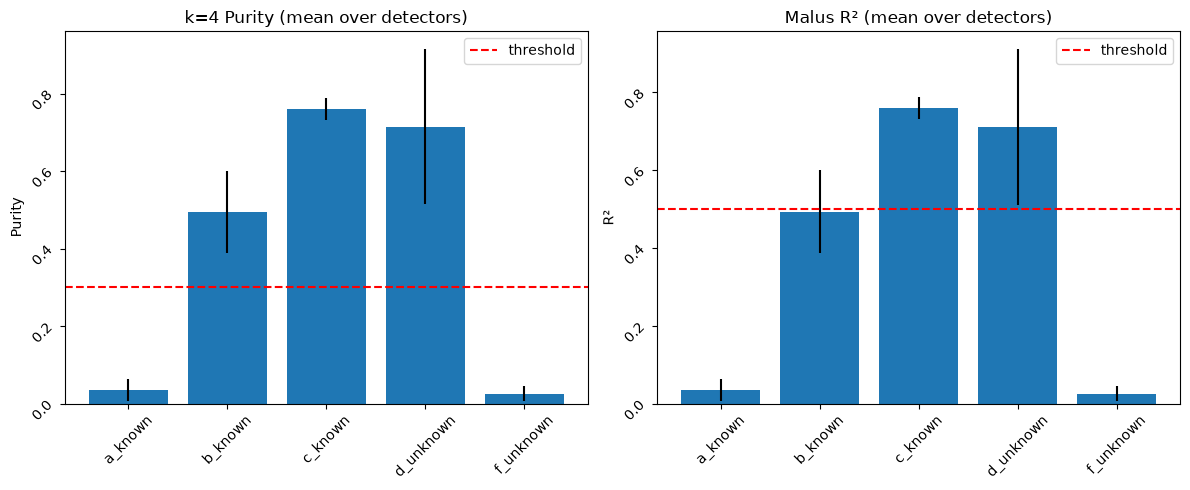

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import detrend

# ----------------------------------------------------------------------
# 1. Data loading and preprocessing (as provided)
# ----------------------------------------------------------------------
def load_dataset(filename):
    df = pd.read_csv(filename)
    num_points_to_read = df.shape[0] // 30 * 30
    df = df.iloc[:num_points_to_read]
    df.iloc[:, 0] = np.arange(num_points_to_read) * 360 / num_points_to_read
    df.rename(columns={df.columns[0]: "angle"}, inplace=True)
    for col in df.columns:
        if col != "angle":
            df[col] = df[col] - df[col].mean()
            df[col] = df[col].round(2)
    df["total"] = df.drop(columns=["angle"]).sum(axis=1)
    sample_frequency = num_points_to_read / 360
    return df, sample_frequency

# Load all phantoms
phantoms = {
    "a_known": [load_dataset(f"data/expt_8_sample_a.csv"), load_dataset(f"data/expt_8_sample_a_redo.csv")],
    "b_known": [load_dataset(f"data/expt_8_sample_b.csv"), load_dataset(f"data/expt_8_sample_b_redo.csv")],
    "c_known": [load_dataset(f"data/expt_8_sample_c.csv"), load_dataset(f"data/expt_8_sample_c_redo.csv")],
    "d_unknown": [load_dataset(f"data/expt_8_sample_d.csv"), load_dataset(f"data/expt_8_sample_d_redo.csv")],
    "f_unknown": [load_dataset(f"data/expt_8_sample_f.csv"), load_dataset(f"data/expt_8_sample_f_redo.csv")],
}

# ----------------------------------------------------------------------
# 2. Per‑detector birefringence analysis
# ----------------------------------------------------------------------
def analyze_detector_signal(angles, signal):
    """
    Compute birefringence metrics for one signal trace.
    Returns dict with k4 amplitude, purity, Malus R², etc.
    """
    N = len(signal)
    # Remove DC and detrend
    signal_dc = signal - np.mean(signal)
    # Detrend (remove slow drift)
    signal_detrend = detrend(signal_dc)
    
    # FFT
    yf = np.fft.fft(signal_detrend)
    mag = 2.0 / N * np.abs(yf[:N//2])
    power = mag[1:]**2          # exclude DC
    total_ac = np.sum(power)
    if total_ac == 0:
        return {"k4_amp": 0, "k4_purity": 0, "malus_r2": 0, "dominant_k": 0}
    
    # Dominant k (index 0 corresponds to k=1)
    dom_k = np.argmax(power) + 1
    k4_power = power[3] if len(power) > 3 else 0
    k4_purity = k4_power / total_ac
    # Amplitude of k4 (peak magnitude at k=4)
    k4_amp = mag[4] if len(mag) > 4 else 0
    
    # Malus fit for k=4
    def malus_k4(theta, A, phi, C):
        return A * np.cos(4 * np.radians(theta) + phi) + C
    
    try:
        # Use the detrended signal for fit (better baseline)
        popt, _ = curve_fit(malus_k4, angles, signal_detrend,
                            p0=[np.std(signal_detrend), 0, 0],
                            maxfev=2000)
        pred = malus_k4(angles, *popt)
        ss_res = np.sum((signal_detrend - pred)**2)
        ss_tot = np.sum((signal_detrend)**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        r2 = max(0, r2)
    except:
        r2 = 0
    
    return {
        "k4_amp": k4_amp,
        "k4_purity": k4_purity,
        "malus_r2": r2,
        "dominant_k": dom_k,
    }

def analyze_phantom(df, signal_col="total"):
    """
    Analyze a single DataFrame (one measurement run) and return metrics
    averaged over all detector columns (excluding angle and total).
    Also returns per-detector results for consistency check.
    """
    angles = df["angle"].values
    detector_cols = [c for c in df.columns if c not in ["angle", "total"]]
    results = []
    for col in detector_cols:
        sig = df[col].values
        res = analyze_detector_signal(angles, sig)
        res["detector"] = col
        results.append(res)
    
    # Average metrics over detectors
    avg = {
        "k4_purity_mean": np.mean([r["k4_purity"] for r in results]),
        "k4_purity_std": np.std([r["k4_purity"] for r in results]),
        "malus_r2_mean": np.mean([r["malus_r2"] for r in results]),
        "malus_r2_std": np.std([r["malus_r2"] for r in results]),
        "k4_amp_mean": np.mean([r["k4_amp"] for r in results]),
        "dominant_k_mode": pd.Series([r["dominant_k"] for r in results]).mode()[0],
    }
    # Also store individual results if needed
    avg["per_detector"] = results
    return avg

# ----------------------------------------------------------------------
# 3. Classification function
# ----------------------------------------------------------------------
def classify_birefringence(metrics, threshold_purity=0.30, threshold_r2=0.5):
    """
    Based on averaged metrics, decide if the phantom is birefringent.
    Returns: "YES" or "NO"
    """
    purity = metrics["k4_purity_mean"]
    r2 = metrics["malus_r2_mean"]
    dom_k = metrics["dominant_k_mode"]
    # Condition: dominant k is 4, purity above threshold, and R² above threshold
    if dom_k == 4 and purity >= threshold_purity and r2 >= threshold_r2:
        return "Birefringent (nerve)"
    else:
        return "Non-birefringent (no nerve)"

# ----------------------------------------------------------------------
# 4. Run analysis for all phantoms
# ----------------------------------------------------------------------
results_list = []
for phantom_name, datasets in phantoms.items():
    run_metrics = []
    for idx, (df, _) in enumerate(datasets):
        met = analyze_phantom(df, signal_col="total")
        met["run"] = idx + 1
        run_metrics.append(met)
    
    # Average over runs for this phantom
    avg_run = {
        "k4_purity_mean": np.mean([m["k4_purity_mean"] for m in run_metrics]),
        "k4_purity_std": np.mean([m["k4_purity_std"] for m in run_metrics]),
        "malus_r2_mean": np.mean([m["malus_r2_mean"] for m in run_metrics]),
        "malus_r2_std": np.mean([m["malus_r2_std"] for m in run_metrics]),
        "k4_amp_mean": np.mean([m["k4_amp_mean"] for m in run_metrics]),
        "dominant_k_mode": pd.Series([m["dominant_k_mode"] for m in run_metrics]).mode()[0],
    }
    avg_run["phantom"] = phantom_name
    avg_run["classification"] = classify_birefringence(avg_run)
    results_list.append(avg_run)

# Create summary DataFrame
summary = pd.DataFrame(results_list)
summary = summary[["phantom", "dominant_k_mode", "k4_purity_mean", "k4_purity_std",
                   "malus_r2_mean", "malus_r2_std", "k4_amp_mean", "classification"]]

print("\n============ BIREFRINGENCE CLASSIFICATION ============\n")
print(summary.to_string(index=False))

# ----------------------------------------------------------------------
# 5. Detailed per‑detector analysis for unknowns (optional)
# ----------------------------------------------------------------------
# For deeper inspection, we can examine the per‑detector metrics of unknowns
for ph in ["d_unknown", "f_unknown"]:
    print(f"\n--- {ph} per‑detector analysis ---")
    datasets = phantoms[ph]
    for idx, (df, _) in enumerate(datasets):
        met = analyze_phantom(df, signal_col="total")
        print(f"  Run {idx+1}:")
        for det in met["per_detector"]:
            print(f"    {det['detector']}: k4 purity={det['k4_purity']:.3f}, R²={det['malus_r2']:.3f}")

# ----------------------------------------------------------------------
# 6. Visualization: Plot metrics for each phantom
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot k4 purity
axes[0].bar(summary["phantom"], summary["k4_purity_mean"], yerr=summary["k4_purity_std"])
axes[0].axhline(y=0.30, color='r', linestyle='--', label='threshold')
axes[0].set_title("k=4 Purity (mean over detectors)")
axes[0].set_ylabel("Purity")
axes[0].tick_params(rotation=45)
axes[0].legend()

# Plot Malus R²
axes[1].bar(summary["phantom"], summary["malus_r2_mean"], yerr=summary["malus_r2_std"])
axes[1].axhline(y=0.5, color='r', linestyle='--', label='threshold')
axes[1].set_title("Malus R² (mean over detectors)")
axes[1].set_ylabel("R²")
axes[1].tick_params(rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()